#### 实验要求
##### 上节实验课第3小题，要求大家完成基于随机梯度下降法的线性分类器更新
##### 要求1 在优化器中加入动量Momentum 补充完整程序
##### 要求2 使用Adam优化器，补充完整程序
##### 要求3 对比分析两种优化器的结果差异

## MNIST数据集读取

In [1]:
import gzip
import os
import struct
import numpy as np
from sklearn.utils import shuffle

def load_mnist(path, kind='train'):
    """加载MNIST数据集"""
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte.gz')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte.gz')

    with gzip.open(labels_path, 'rb') as lbpath:
        struct.unpack('>II', lbpath.read(8))
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8)

    with gzip.open(images_path, 'rb') as imgpath:
        struct.unpack('>IIII', imgpath.read(16))
        images = np.frombuffer(imgpath.read(), dtype=np.uint8).reshape(len(labels), 784)

    return images, labels

# 数据集划分
def data_split(images, labels, ratio):
    total_len = images.shape[0]
    offset = int(total_len * ratio)

    val_img = images[:offset][:]
    val_lb = labels[:offset]

    train_img = images[offset:][:]
    train_lb = labels[offset:]

    return train_img, train_lb, val_img, val_lb

# 读取训练集和测试集数据
[images, labels] = load_mnist('../MNIST', kind='train')
[test_img, test_lb] = load_mnist('../MNIST', kind='test')

images, labels = shuffle(images, labels, random_state=42)

train_img, train_lb, val_img, val_lb = data_split(images, labels, 1/6)

# 打印查看数据集格式
print('训练集图像格式为:', train_img.shape, '训练集标签格式为:', train_lb.shape)
print('验证集图像格式为:', val_img.shape, '验证集标签格式为:', val_lb.shape)
print('测试集图像格式为:', test_img.shape, '测试集标签格式为:', test_lb.shape)
print('最大像素值:', train_img.max()) 
print('最小像素值:', train_img.min())

训练集图像格式为: (50000, 784) 训练集标签格式为: (50000,)
验证集图像格式为: (10000, 784) 验证集标签格式为: (10000,)
测试集图像格式为: (10000, 784) 测试集标签格式为: (10000,)
最大像素值: 255
最小像素值: 0


## 用SGD+Momentum+CrossEntropyLoss来训练 Linear Classifier

### 定义Cross Entropy Loss

In [34]:
def vectorized_loss_softmax(X, y, W):
    """
    Inputs have dimension D=784, there are C=10 classes, and we operate on N=50000 examples.
    
    Inputs:
    - W: Indexs of linear classifier, a numpy array of shape (D, C) containing weights.
    - X: Training images, a numpy array of shape (N, D) containing a minibatch of data.
    - y: Training labels, a numpy array of shape (N,) containing training labels; y[i] = c means
         that X[i] has label c, where 0 <= c < C.
    
    Returns a tuple of:
    - Softmax loss as single float.
    """
    
    # set the value of delta, lamda
    delta = 1.0
    lamda = 1.0
    num_train = X.shape[0]
    num_class = W.shape[1]
    
    # scores: class x examples
    scores = W.T.dot(X.T).reshape(num_class, num_train)
    
    # scores_max: 1 x examples, get the max value from each column
    scores_max = np.reshape(np.max(scores, axis=0), (1, num_train))

    # prob: class x examples, calculate the log probability
    # use scores_max to limit the boundary of exp indexes
    prob = np.exp(scores-scores_max) / np.sum(np.exp(scores-scores_max), axis=0)

    # set value 1 in true label positions, 0 for false labels
    y_true = np.zeros(prob.shape)
    y_true[y, np.arange(num_train)] = 1.0
    
    # calculate the average data loss
    loss = -np.sum(y_true * np.log(prob))/num_train
    
    # add L1 regularization loss
    rw = np.sum(np.abs(W))
    loss += lamda * rw
    
    return loss

### 定义梯度计算函数

In [35]:
# compute the numeric gradient
def compute_gradient(img, lb, X):
    """
    Inputs have dimension D=784, there are C=10 classes, and we operate on N=1000 examples.
    
    Inputs:
    - img: Training images, a numpy array of shape (N, D) containing a minibatch of data.
    - lb: Training labels, a numpy array of shape (N,) containing training labels; y[i] = c means
          that X[i] has label c, where 0 <= c < C.
    - X: Indexs of linear classifier, a numpy array of shape (D, C) containing weights.
    
    Returns:
    - Numeric gradient dx
    """
    
    # initalize the gradient matrix dx
    dx = np.zeros(X.shape)
    h = 0.0001
    
    # calculate the inital loss fx
    fx = vectorized_loss_softmax(img, lb, X)
    
    # iterate the each value
    for c in range(X.shape[1]):
        for d in range(X.shape[0]):
            # evaluate function(x+h)
            org_val = X[d][c]

            # increment by h
            X[d][c] = org_val + h

            # evalute the softmax loss for f(x+h)
            fxh = vectorized_loss_softmax(img, lb, X)

            # restore to previous value
            X[d][c] = org_val

            # compute the partial derivative
            dx[d][c] = (fxh - fx) / h

    return dx


### 定义SGD+Momentum优化器

In [36]:

# SGD training function
def Train_with_SGD(img, lb, epoch):
    """
    Inputs have dimension D=784, there are C=10 classes, and we operate on N=1000 examples.
    
    Inputs:
    - img: Training images, a numpy array of shape (N, D) containing a minibatch of data.
    - lb: Training labels, a numpy array of shape (N,) containing training labels; y[i] = c means
          that X[i] has label c, where 0 <= c < C.
    - epoch: Training iterations, an integer.
    
    Returns:
    - Best indexs X
    """
    
    # set the hyperparameters
    beta1 = 0.9
    beta2 = 0.999
    learning_rate = 1e-4
    first_momentum = 0
    second_momentum = 0
    
    # initialize the indexs X
    X = np.random.randn(img.shape[1], 10) * 0.0001

    loss_his = []
    acc_his = []
    
    # start training
    for i in range(1, epoch + 1):
        # compute the gradient
        dx = compute_gradient(img, lb, X)
        
        # momentum
        first_momentum = beta1 * first_momentum + (1-beta1) * dx
        
        # update the indexs X
        X -= learning_rate * first_momentum
        
        # calculate the loss and accuracy
        loss = vectorized_loss_softmax(img, lb, X)
        scores =  X.T.dot(img.T)
        y_pred = np.argmax(scores, axis=0)
        accuracy = np.mean(y_pred == lb) * 100

        loss_his.append(loss)
        acc_his.append(accuracy)
        
        # print the result
        print("Epoch: %d  Loss: %.3f  Acc: %.3f%%" % (i, loss, accuracy))
    
    return X, loss_his, acc_his

### 在训练集上进行训练

In [37]:
# train the linear classifier with adam in 1000 examples
epoch = 10
best_X, loss_his1, acc_his1 = Train_with_SGD(train_img[0:1000,:], train_lb[0:1000], epoch)

Epoch: 1  Loss: 2.360  Acc: 47.200%
Epoch: 2  Loss: 1.752  Acc: 78.800%
Epoch: 3  Loss: 1.564  Acc: 80.300%
Epoch: 4  Loss: 1.543  Acc: 85.100%
Epoch: 5  Loss: 1.622  Acc: 85.700%
Epoch: 6  Loss: 1.728  Acc: 86.600%
Epoch: 7  Loss: 1.808  Acc: 87.600%
Epoch: 8  Loss: 1.850  Acc: 89.400%
Epoch: 9  Loss: 1.869  Acc: 90.000%
Epoch: 10  Loss: 1.855  Acc: 90.900%


### 在验证集上测试分类效果

In [38]:
# test the classification accuracy on validation dataset

# scores: class x examples
scores =  best_X.T.dot(val_img.T)

# get the predicted labels
# y_pred: examples
y_pred = np.argmax(scores, axis=0)

# calculate the accuracy
accuracy = np.mean(y_pred == val_lb) * 100

# print the accuracy
print("SGD_Momentum优化器在验证集上的分类精度为: %.3f%%" % accuracy)

SGD_Momentum优化器在验证集上的分类精度为: 85.510%


## 使用Adam优化器进行训练

### 定义Adam

In [8]:

# Adam training function
def Train_with_Adam(img, lb, epoch):
    """
    Inputs have dimension D=784, there are C=10 classes, and we operate on N=1000 examples.
    
    Inputs:
    - img: Training images, a numpy array of shape (N, D) containing a minibatch of data.
    - lb: Training labels, a numpy array of shape (N,) containing training labels; y[i] = c means
          that X[i] has label c, where 0 <= c < C.
    - epoch: Training iterations, an integer.
    
    Returns:
    - Best indexs X
    """
    
    # set the hyperparameters
    beta1 = 0.9
    beta2 = 0.999
    learning_rate = 5e-5
    first_momentum = 0
    second_momentum = 0
    
    # initialize the indexs X
    X = np.random.randn(img.shape[1], 10) * 0.0001

    loss_his = []
    acc_his = []
    
    # start training
    for i in range(1, epoch + 1):
        # compute the gradient
        dx = compute_gradient(img, lb, X)
        
        # momentum
        first_momentum = beta1 * first_momentum + (1-beta1) * dx
        # adagrad
        second_momentum = beta2 * second_momentum + (1-beta2) * dx * dx
        
        # bias correction
        first_unbias = first_momentum / (1 - beta1 ** i)
        second_unbias = second_momentum / (1 - beta2 ** i)
        
        # update the indexs X
        X = X - learning_rate * first_unbias / (np.sqrt(second_unbias) + 1e-7)
        
        # calculate the loss and accuracy
        loss = vectorized_loss_softmax(img, lb, X)
        scores =  X.T.dot(img.T)
        y_pred = np.argmax(scores, axis=0)
        accuracy = np.mean(y_pred == lb) * 100

        loss_his.append(loss)
        acc_his.append(accuracy)
        
        # print the result
        print("Epoch: %d  Loss: %.3f  Acc: %.3f%%" % (i, loss, accuracy))
    
    return X, loss_his, acc_his

### 在训练集上进行训练

In [9]:
# train the linear classifier with adam in 1000 examples
epoch = 10
best_X, loss_his2, acc_his2 = Train_with_Adam(train_img[0:1000,:], train_lb[0:1000], epoch)

Epoch: 1  Loss: 2.370  Acc: 44.300%
Epoch: 2  Loss: 1.993  Acc: 72.600%
Epoch: 3  Loss: 1.804  Acc: 82.900%
Epoch: 4  Loss: 1.728  Acc: 82.700%
Epoch: 5  Loss: 1.689  Acc: 83.300%
Epoch: 6  Loss: 1.660  Acc: 84.400%
Epoch: 7  Loss: 1.637  Acc: 85.000%
Epoch: 8  Loss: 1.611  Acc: 86.000%
Epoch: 9  Loss: 1.583  Acc: 87.000%
Epoch: 10  Loss: 1.555  Acc: 88.100%


### 在验证集上测试分类效果

In [10]:
# test the classification accuracy on validation dataset

# scores: class x examples
scores =  best_X.T.dot(val_img.T)

# get the predicted labels
# y_pred: examples
y_pred = np.argmax(scores, axis=0)

# calculate the accuracy
accuracy = np.mean(y_pred == val_lb) * 100

# print the accuracy
print("SGD_Momentum优化器在验证集上的分类精度为: %.3f%%" % accuracy)

SGD_Momentum优化器在验证集上的分类精度为: 83.480%


## 结果分析

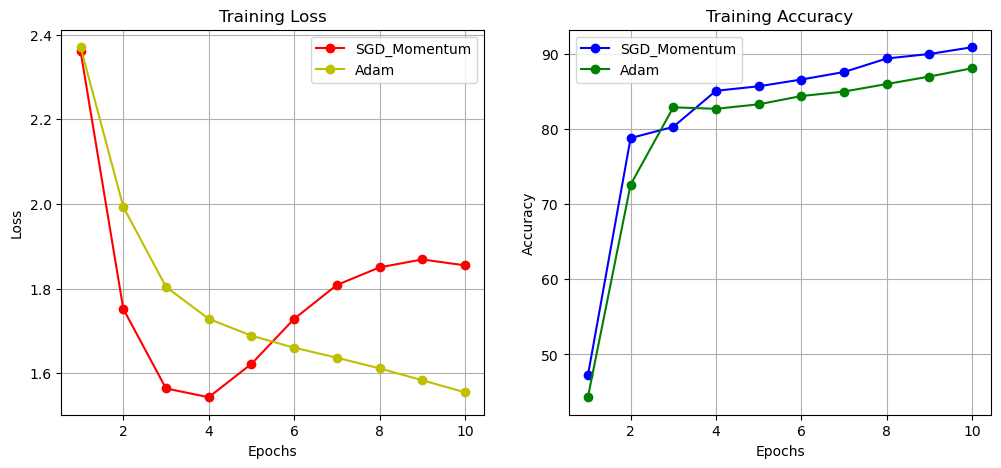

In [39]:
import matplotlib.pyplot as plt

epochs = range(1, epoch + 1)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, loss_his1, 'r-o', label='SGD_Momentum')
plt.plot(epochs, loss_his2, 'y-o', label='Adam')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs, acc_his1, 'b-o', label='SGD_Momentum')
plt.plot(epochs, acc_his2, 'g-o', label='Adam')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

### 实验结果对比
1. 训练损失（Loss）  
SGD+Momentum：损失从初始2.36下降到第四轮的1.54，之后又上升至第九轮的1.869后又开始下降
Adam：损失从 2.37 下降到 1.56 左右，最终损失更低

2. 训练准确率（Accuracy）  
SGD+Momentum：从 47.2% 提升到 90.9%
Adam：从 44.3% 提升到 88.1%

3. 验证集准确率  
SGD+Momentum：85.51%
Adam：83.48%

### 结果分析
Adam收敛更快，在每轮训练中都能更快地降低损失，说明其自适应学习率机制在小批量数据上表现良好，但可能存在过拟合倾向，训练集上表现更好，但验证集略差  
SGD+Momentum收敛较慢，但后期稳步提升，最终训练准确率更高，泛化能力更好，虽然训练准确率与 Adam 相近，但在验证集上表现更优，说明其泛化能力略强



